<a href="https://colab.research.google.com/github/oumaymazerrik/Fake_news/blob/main/File.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **1. Installation et imports**


In [ ]:
!pip install -q kagglehub transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import os
import gc
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

CUDA disponible : True
GPU : Tesla T4


In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "clmentbisaillon/fake-and-real-news-dataset"
)

print("Dataset téléchargé dans :")
print(path)

print("\nFichiers :")
print(os.listdir(path))

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Dataset téléchargé dans :
/kaggle/input/fake-and-real-news-dataset

Fichiers :
['True.csv', 'Fake.csv']


In [ ]:
fake_path = os.path.join(path, "Fake.csv")
true_path = os.path.join(path, "True.csv")

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake :", fake_df.shape)
print("True :", true_df.shape)

display(fake_df.head())
display(true_df.head())

Fake : (23481, 4)
True : (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake_df["label"] = 0
true_df["label"] = 1

print("Fake :", fake_df.shape)
print("True :", true_df.shape)

Fake : (23481, 5)
True : (21417, 5)


In [ ]:
df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Dataset total :", df.shape)

display(df.head())

Dataset total : (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [ ]:
print("Nombre par classe :")
print(df["label"].value_counts())

print("\nPourcentage :")
print(df["label"].value_counts(normalize=True) * 100)

Nombre par classe :
label
0    23481
1    21417
Name: count, dtype: int64

Pourcentage :
label
0    52.298543
1    47.701457
Name: proportion, dtype: float64


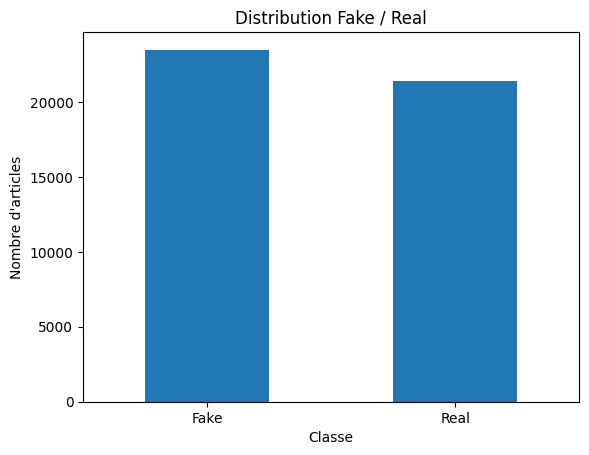

In [ ]:
df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["Fake", "Real"],
    rotation=0
)

plt.xlabel("Classe")
plt.ylabel("Nombre d'articles")
plt.title("Distribution Fake / Real")

plt.show()

In [ ]:
print(df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [ ]:
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

df = df[
    (df["title"].str.strip() != "") |
    (df["text"].str.strip() != "")
].copy()

print("Dataset après nettoyage :", df.shape)

Dataset après nettoyage : (44898, 5)


In [ ]:
df["content"] = (
    df["title"].astype(str)
    + " "
    + df["text"].astype(str)
)

X = df["content"]
y = df["label"]

print(X.shape)
print(y.shape)

(44898,)
(44898,)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

Train      : 35918
Validation : 4490
Test       : 4490


In [ ]:
print("\nTRAIN")
print(y_train.value_counts(normalize=True))

print("\nVALIDATION")
print(y_val.value_counts(normalize=True))

print("\nTEST")
print(y_test.value_counts(normalize=True))


TRAIN
label
0    0.522997
1    0.477003
Name: proportion, dtype: float64

VALIDATION
label
0    0.52294
1    0.47706
Name: proportion, dtype: float64

TEST
label
0    0.52294
1    0.47706
Name: proportion, dtype: float64


In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

start = time.time()

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

tfidf_time = time.time() - start

print("Train :", X_train_tfidf.shape)
print("Val   :", X_val_tfidf.shape)
print("Test  :", X_test_tfidf.shape)

print(f"\nTF-IDF : {tfidf_time:.2f} sec")

Train : (35918, 50000)
Val   : (4490, 50000)
Test  : (4490, 50000)

TF-IDF : 46.80 sec


In [ ]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

start = time.time()

lr_baseline.fit(
    X_train_tfidf,
    y_train
)

lr_training_time = time.time() - start

print(
    f"Entraînement Logistic Regression : "
    f"{lr_training_time:.2f} sec"
)

Entraînement Logistic Regression : 1.71 sec


In [ ]:
y_val_pred = lr_baseline.predict(X_val_tfidf)

print("VALIDATION")

print(
    "Accuracy :",
    accuracy_score(y_val, y_val_pred)
)

print(
    "F1 :",
    f1_score(y_val, y_val_pred)
)

print()

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Fake", "Real"]
    )
)

VALIDATION
Accuracy : 0.9879732739420936
F1 : 0.9874418604651163

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2348
        Real       0.98      0.99      0.99      2142

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490



In [ ]:
start = time.time()

y_test_pred = lr_baseline.predict(
    X_test_tfidf
)

baseline_inference_time = time.time() - start


baseline_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

baseline_f1 = f1_score(
    y_test,
    y_test_pred
)

baseline_precision = precision_score(
    y_test,
    y_test_pred
)

baseline_recall = recall_score(
    y_test,
    y_test_pred
)

baseline_time = (
    tfidf_time +
    lr_training_time
)


print("===== BASELINE =====")

print(
    f"Accuracy  : {baseline_accuracy:.4f}"
)

print(
    f"Precision : {baseline_precision:.4f}"
)

print(
    f"Recall    : {baseline_recall:.4f}"
)

print(
    f"F1        : {baseline_f1:.4f}"
)

print(
    f"Training time : {baseline_time:.2f} sec"
)

===== BASELINE =====
Accuracy  : 0.9880
Precision : 0.9829
Recall    : 0.9921
F1        : 0.9875
Training time : 48.50 sec


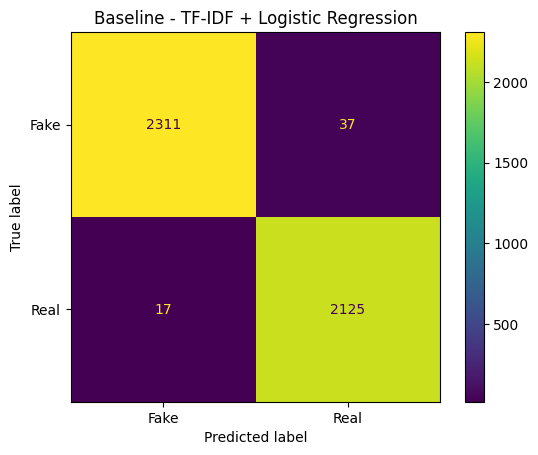

In [ ]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title(
    "Baseline - TF-IDF + Logistic Regression"
)

plt.show()

In [ ]:
baseline_results = pd.DataFrame({
    "text": X_test.values,
    "true": y_test.values,
    "prediction": y_test_pred
})

baseline_errors = baseline_results[
    baseline_results["true"]
    != baseline_results["prediction"]
]

print(
    "Nombre d'erreurs :",
    len(baseline_errors)
)

Nombre d'erreurs : 54


In [ ]:
for _, row in baseline_errors.head(2).iterrows():

    print("=" * 100)

    print(
        "Vraie classe :",
        "REAL" if row["true"] == 1 else "FAKE"
    )

    print(
        "Prédiction :",
        "REAL" if row["prediction"] == 1 else "FAKE"
    )

    print("\nArticle :")

    print(row["text"][:1500])

    print()

Vraie classe : FAKE
Prédiction : REAL

Article :
JUST IN: TRUMP ENDS FREE MONEY TRAIN After Pakistan Refuses To Stop Housing Terrorists…Cuts STUNNING About Of Military Aid  The Trump administration on Friday announced the United States will deny Pakistan military aid amounting to $255 million as it expects Islamabad to take decisive action  against terrorists and militants on its soil . The United States does not plan to spend the $255 million in FY 2016 in Foreign Military Financing for Pakistan at this time,  said a spokesperson of the President s National Security Council in a statement to Hindustan Times. The President has made clear that the United States expects Pakistan to take decisive action against terrorists and militants on its soil, and that Pakistan s actions in support of the South Asia Strategy will ultimately determine the trajectory of our relationship, including future security assistance. The Administration continues to review Pakistan s level of cooperation. The st

In [ ]:
del X_train_tfidf
del X_val_tfidf
del X_test_tfidf

gc.collect()

print("RAM libérée.")

RAM libérée.


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModel
)

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

plm_model = AutoModel.from_pretrained(
    MODEL_NAME
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

plm_model = plm_model.to(device)

plm_model.eval()

print("Device :", device)

print(
    "Model device :",
    next(plm_model.parameters()).device
)

Device : cuda
Model device : cuda:0


In [ ]:
for param in plm_model.parameters():
    param.requires_grad = False

print(
    "Paramètres entraînables :",
    sum(
        p.numel()
        for p in plm_model.parameters()
        if p.requires_grad
    )
)

Paramètres entraînables : 0


In [ ]:
from tqdm.auto import tqdm

def extract_embeddings(
    texts,
    batch_size=64,
    max_length=128
):

    embeddings = []

    texts = list(texts)

    for i in tqdm(
        range(0, len(texts), batch_size),
        desc="Extraction embeddings"
    ):

        batch = texts[
            i:i + batch_size
        ]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        inputs = {
            k: v.to(device)
            for k, v in inputs.items()
        }

        with torch.inference_mode():

            outputs = plm_model(
                **inputs
            )

        # DistilBERT :
        # premier token = représentation globale
        batch_embeddings = (
            outputs.last_hidden_state[:, 0, :]
        )

        embeddings.append(
            batch_embeddings
            .cpu()
            .numpy()
        )

    return np.vstack(embeddings)

In [ ]:
test_emb = extract_embeddings(
    X_train.iloc[:100]
)

print(test_emb.shape)

Extraction embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

(100, 768)


In [ ]:
start = time.time()

X_train_plm = extract_embeddings(
    X_train
)

plm_train_extraction_time = (
    time.time() - start
)

print(
    "Train embeddings :",
    X_train_plm.shape
)

print(
    f"Temps : "
    f"{plm_train_extraction_time/60:.2f} min"
)

Extraction embeddings:   0%|          | 0/562 [00:00<?, ?it/s]

Train embeddings : (35918, 768)
Temps : 2.68 min


In [ ]:
start = time.time()

X_val_plm = extract_embeddings(
    X_val
)

X_test_plm = extract_embeddings(
    X_test
)

plm_other_extraction_time = (
    time.time() - start
)

print(X_val_plm.shape)
print(X_test_plm.shape)

Extraction embeddings:   0%|          | 0/71 [00:00<?, ?it/s]

Extraction embeddings:   0%|          | 0/71 [00:00<?, ?it/s]

(4490, 768)
(4490, 768)


In [ ]:
lr_plm = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

start = time.time()

lr_plm.fit(
    X_train_plm,
    y_train
)

plm_classifier_time = (
    time.time() - start
)

print(
    f"Classification : "
    f"{plm_classifier_time:.2f} sec"
)

Classification : 4.13 sec


In [ ]:
y_plm_pred = lr_plm.predict(
    X_test_plm
)

plm_accuracy = accuracy_score(
    y_test,
    y_plm_pred
)

plm_f1 = f1_score(
    y_test,
    y_plm_pred
)

plm_precision = precision_score(
    y_test,
    y_plm_pred
)

plm_recall = recall_score(
    y_test,
    y_plm_pred
)

plm_time = (
    plm_train_extraction_time
    + plm_other_extraction_time
    + plm_classifier_time
)

print("===== PLM GELÉ =====")

print(
    f"Accuracy  : {plm_accuracy:.4f}"
)

print(
    f"Precision : {plm_precision:.4f}"
)

print(
    f"Recall    : {plm_recall:.4f}"
)

print(
    f"F1        : {plm_f1:.4f}"
)

print(
    f"Temps total : "
    f"{plm_time/60:.2f} min"
)

===== PLM GELÉ =====
Accuracy  : 0.9940
Precision : 0.9935
Recall    : 0.9939
F1        : 0.9937
Temps total : 3.45 min


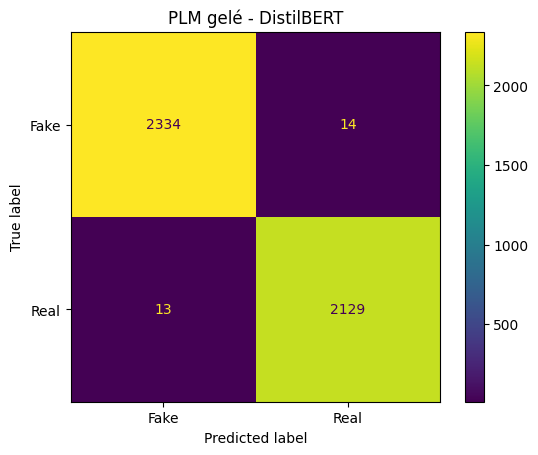

In [ ]:
cm_plm = confusion_matrix(
    y_test,
    y_plm_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_plm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title(
    "PLM gelé - DistilBERT"
)

plt.show()

Fine-tunning

In [ ]:
del plm_model

del X_train_plm
del X_val_plm
del X_test_plm

gc.collect()

torch.cuda.empty_cache()

print("GPU nettoyé.")

GPU nettoyé.


In [ ]:
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

In [ ]:
train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 35918
})
Dataset({
    features: ['text', 'label'],
    num_rows: 4490
})
Dataset({
    features: ['text', 'label'],
    num_rows: 4490
})


In [ ]:
MODEL_NAME = "distilbert-base-uncased"

ft_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

ft_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=2
    )
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def tokenize_function(examples):

    return ft_tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

In [ ]:
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

Map:   0%|          | 0/35918 [00:00<?, ? examples/s]

Map:   0%|          | 0/4490 [00:00<?, ? examples/s]

Map:   0%|          | 0/4490 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorWithPadding(
    tokenizer=ft_tokenizer
)

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/distilbert_fake_news",

    num_train_epochs=3,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,

    learning_rate=2e-5,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=SEED
)

In [ ]:
trainer = Trainer(
    model=ft_model,

    args=training_args,

    train_dataset=train_tokenized,

    eval_dataset=val_tokenized,

    processing_class=ft_tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [ ]:
start = time.time()

train_result = trainer.train()

finetuning_time = (
    time.time() - start
)

print(
    f"Fine-tuning : "
    f"{finetuning_time/60:.2f} minutes"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.005487,0.001630,0.999555,1.000000,0.999066,0.999533
2,0.002022,0.000930,0.999777,0.999533,1.000000,0.999767
3,0.000068,0.000697,0.999777,0.999533,1.000000,0.999767


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning : 6.67 minutes


In [ ]:
ft_results = trainer.evaluate(
    test_tokenized
)

print("===== FINE-TUNING =====")

for key, value in ft_results.items():

    print(
        f"{key} : {value}"
    )

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000068,0.002406,3,0.999555,1.000000,0.999066,0.999533


===== FINE-TUNING =====
eval_loss : 0.00240606558509171
eval_accuracy : 0.999554565701559
eval_precision : 1.0
eval_recall : 0.9990662931839402
eval_f1 : 0.9995329285380663


In [ ]:
ft_accuracy = ft_results[
    "eval_accuracy"
]

ft_f1 = ft_results[
    "eval_f1"
]

ft_precision = ft_results[
    "eval_precision"
]

ft_recall = ft_results[
    "eval_recall"
]

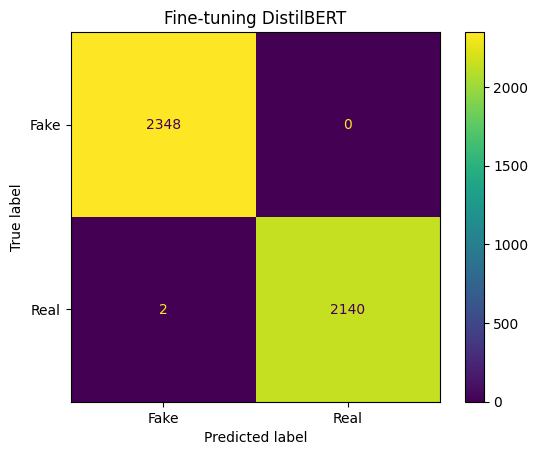

In [ ]:
predictions = trainer.predict(
    test_tokenized
)

y_ft_pred = np.argmax(
    predictions.predictions,
    axis=1
)

cm_ft = confusion_matrix(
    y_test,
    y_ft_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title(
    "Fine-tuning DistilBERT"
)

plt.show()

In [ ]:
history = trainer.state.log_history

eval_logs = [
    log
    for log in history
    if "eval_loss" in log
]

for log in eval_logs:
    print(log)

{'eval_loss': 0.0016303331358358264, 'eval_accuracy': 0.999554565701559, 'eval_precision': 1.0, 'eval_recall': 0.9990662931839402, 'eval_f1': 0.9995329285380663, 'eval_runtime': 4.0997, 'eval_samples_per_second': 1095.201, 'eval_steps_per_second': 17.318, 'epoch': 1.0, 'step': 1123}
{'eval_loss': 0.000930210342630744, 'eval_accuracy': 0.9997772828507795, 'eval_precision': 0.9995333644423705, 'eval_recall': 1.0, 'eval_f1': 0.9997666277712952, 'eval_runtime': 4.2829, 'eval_samples_per_second': 1048.351, 'eval_steps_per_second': 16.577, 'epoch': 2.0, 'step': 2246}
{'eval_loss': 0.0006973918643780053, 'eval_accuracy': 0.9997772828507795, 'eval_precision': 0.9995333644423705, 'eval_recall': 1.0, 'eval_f1': 0.9997666277712952, 'eval_runtime': 4.1386, 'eval_samples_per_second': 1084.909, 'eval_steps_per_second': 17.156, 'epoch': 3.0, 'step': 3369}
{'eval_loss': 0.00240606558509171, 'eval_accuracy': 0.999554565701559, 'eval_precision': 1.0, 'eval_recall': 0.9990662931839402, 'eval_f1': 0.99953

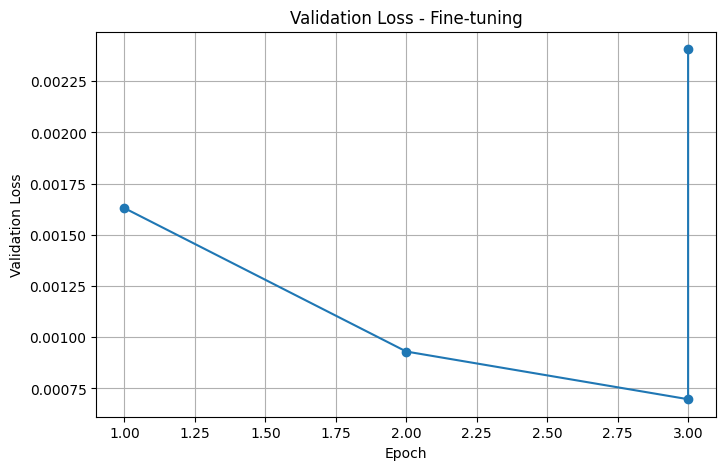

In [ ]:
epochs = [
    log["epoch"]
    for log in eval_logs
]

val_losses = [
    log["eval_loss"]
    for log in eval_logs
]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation Loss - Fine-tuning"
)

plt.grid()

plt.show()

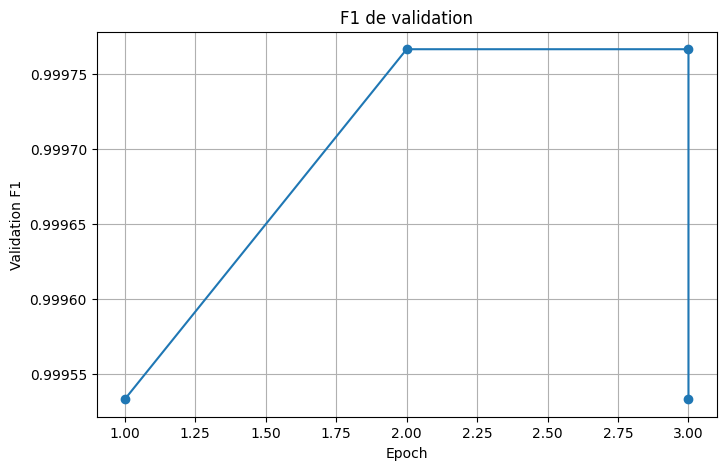

In [ ]:
val_f1_scores = [
    log["eval_f1"]
    for log in eval_logs
]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_f1_scores,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation F1")

plt.title(
    "F1 de validation"
)

plt.grid()

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Approche": [
        "TF-IDF + Logistic Regression",
        "DistilBERT gelé + LR",
        "DistilBERT Fine-tuning"
    ],

    "Accuracy": [
        baseline_accuracy,
        plm_accuracy,
        ft_accuracy
    ],

    "F1": [
        baseline_f1,
        plm_f1,
        ft_f1
    ],

    "Temps_secondes": [
        baseline_time,
        plm_time,
        finetuning_time
    ],

    "GPU": [
        "Non",
        "T4",
        "T4"
    ]
})

comparison

,Approche,Accuracy,F1,Temps_secondes,GPU
0,TF-IDF + Logistic Regression,0.987973,0.987454,48.504715,Non
1,DistilBERT gelé + LR,0.993987,0.993699,207.076402,T4
2,DistilBERT Fine-tuning,0.999555,0.999533,400.453439,T4


In [ ]:
comparison["Accuracy"] = (
    comparison["Accuracy"]
    .round(4)
)

comparison["F1"] = (
    comparison["F1"]
    .round(4)
)

comparison["Temps_secondes"] = (
    comparison["Temps_secondes"]
    .round(2)
)

display(comparison)

,Approche,Accuracy,F1,Temps_secondes,GPU
0,TF-IDF + Logistic Regression,0.9880,0.9875,48.50,Non
1,DistilBERT gelé + LR,0.9940,0.9937,207.08,T4
2,DistilBERT Fine-tuning,0.9996,0.9995,400.45,T4


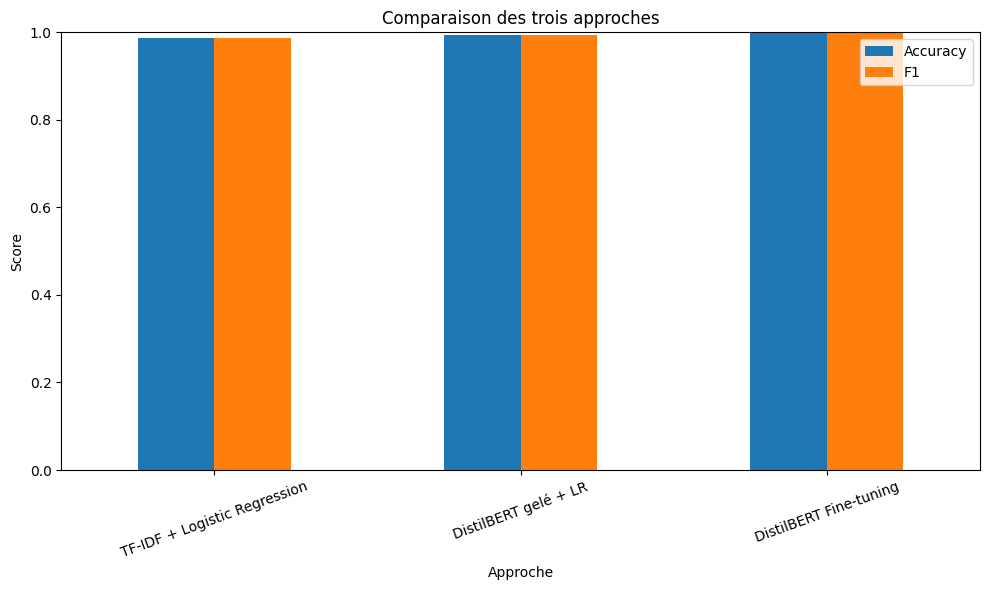

In [ ]:
comparison.set_index("Approche")[
    ["Accuracy", "F1"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1)

plt.ylabel("Score")

plt.title(
    "Comparaison des trois approches"
)

plt.xticks(rotation=20)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
comparison.to_csv(
    "/content/resultats_TP1.csv",
    index=False
)

print("Résultats sauvegardés.")

Résultats sauvegardés.
